C:\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - loss: 0.0011
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 4.1936e-05
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 4.2479e-05
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 4.3206e-05
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 3.8710e-05
Epoch 6/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 4.1844e-05
Epoch 7/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 3.6888e-05
Epoch 8/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 4.0400e-05
Epoch 9/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 3.7643e-05
Epoch 10/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 3.3575e-05
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


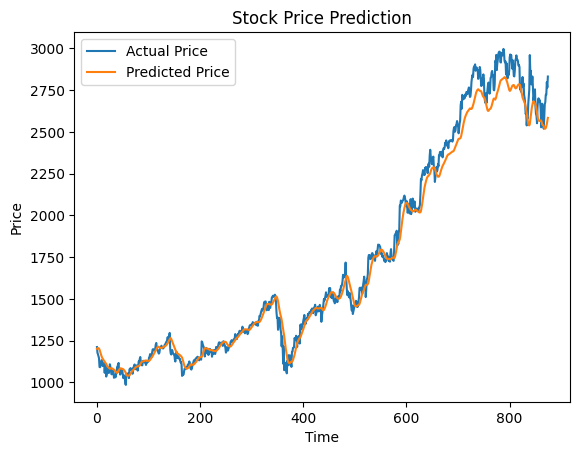

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1. Load dataset
df = pd.read_csv("GOOGL.csv")   # change filename if needed

# 2. Use closing price
data = df['Close'].values.reshape(-1, 1)

# 3. Normalize
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# 4. Create sequences
X = []
y = []

time_steps = 60   # use last 60 days

for i in range(time_steps, len(data_scaled)):
    X.append(data_scaled[i-time_steps:i])
    y.append(data_scaled[i])

X, y = np.array(X), np.array(y)

# 5. Split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 6. Build RNN (LSTM)
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X.shape[1], 1)),
    LSTM(50),
    Dense(1)
])

# 7. Compile
model.compile(optimizer='adam', loss='mse')

# 8. Train
model.fit(X_train, y_train, epochs=10, batch_size=32)

# 9. Predict
predicted = model.predict(X_test)

# Convert back to original scale
predicted = scaler.inverse_transform(predicted)
y_test_actual = scaler.inverse_transform(y_test)

# 10. Plot results (MEANINGFUL OUTPUT)
plt.plot(y_test_actual, label='Actual Price')
plt.plot(predicted, label='Predicted Price')
plt.title("Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()